# градиентные методы оптимизации на практике


In [1]:
import numpy as np

def rosenbrock(x):
    return np.sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1 - x[:-1]) ** 2.0, axis=0)

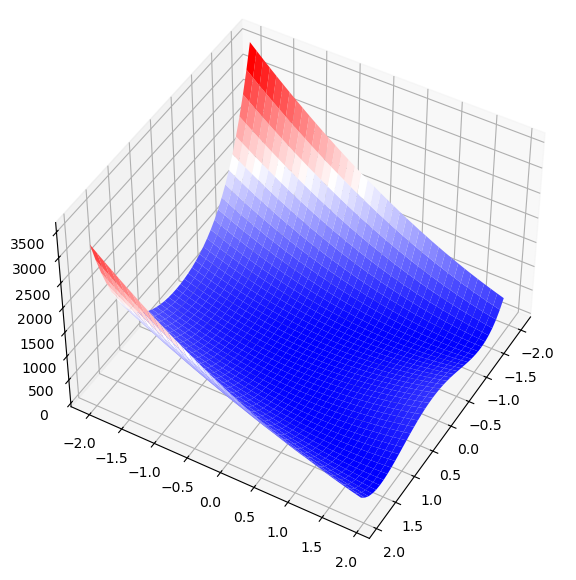

In [20]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(45, 30)


x = np.arange(-2, 2, 0.1) # создает массив чисел от -2 до 2 с шагом 0.1
y = np.arange(-2, 2, 0.1) # создает массив чисел от -2 до 2 с шагом 0.1
# np.meshgrid создает двумерные матрицы координат из одномерных массивов, 
# где количество строк в результирующих матрицах соответствует количеству значений в массиве, 
# переданном как второй аргумент, 
# а количество столбцов соответствует количеству значений в первом массиве, 
# что позволяет получить все возможные комбинации значений для дальнейших вычислений и визуализации.
X, Y = np.meshgrid(x, y)  
Z = rosenbrock(np.array([X, Y]))

surf = ax.plot_surface(X, Y, Z, cmap='bwr')

plt.show()

In [22]:
# создам начальную точку, для поиска
x0 = np.array([-1.2, 0.7, 2.1]) # 3-мерный вектор

# использую Нелдера-Мида для поиска минимума
from scipy.optimize import minimize

res = minimize(rosenbrock, x0, method='Nelder-Mead', options={'xtol': 1e-8, 'disp': True})
print(res.x)

Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 202
         Function evaluations: 355
[0.99999173 0.99998991 0.99998069]


/tmp/ipykernel_7443/2075448876.py:7: OptimizeWarning: Unknown solver options: xtol
  res = minimize(rosenbrock, x0, method='Nelder-Mead', options={'xtol': 1e-8, 'disp': True})


In [24]:
def rosen_der(x):
    xm = x[1:-1]
    xm_m1 = x[:-2]
    xm_p1 = x[2:]
    der = np.zeros_like(x)
    der[1:-1] = 200*(xm-xm_m1**2) - 400*(xm_p1 - xm**2)*xm - 2*(1-xm)
    der[0] = -400*x[0]*(x[1]-x[0]**2) - 2*(1-x[0])
    der[-1] = 200*(x[-1]-x[-2]**2)
    return der


# BFGS - метод Бройдена-Флетчера-Гольдфарба-Шанно градиентный метод
# jac - градиент функции(rosen_der)

res = minimize(rosenbrock, x0, method='BFGS', jac=rosen_der, options={'disp': True})
print(res.x)


Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 30
         Function evaluations: 38
         Gradient evaluations: 38
[1.00000014 1.00000029 1.00000056]


In [25]:

# матрица Гессе
def rosen_hess(x):
    x = np.asarray(x)
    H = np.diag(-400*x[:-1],1) - np.diag(400*x[:-1],-1)
    diagonal = np.zeros_like(x)
    diagonal[0] = 1200*x[0]**2-400*x[1]+2
    diagonal[-1] = 200
    diagonal[1:-1] = 202 + 1200*x[1:-1]**2 - 400*x[2:]
    H = H + np.diag(diagonal)
    return H

res = minimize(rosenbrock, x0, method='Newton-CG', jac=rosen_der, hess=rosen_hess, options={'disp': True})
print(res.x)


    


Optimization terminated successfully.
         Current function value: 0.000000
         Iterations: 145
         Function evaluations: 183
         Gradient evaluations: 183
         Hessian evaluations: 145
[0.99999998 0.99999997 0.99999994]


# метод дифференциальной эволюции

In [1]:
import numpy as np

def rosenbrock(x):
    return np.sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1 - x[:-1]) ** 2.0, axis=0)

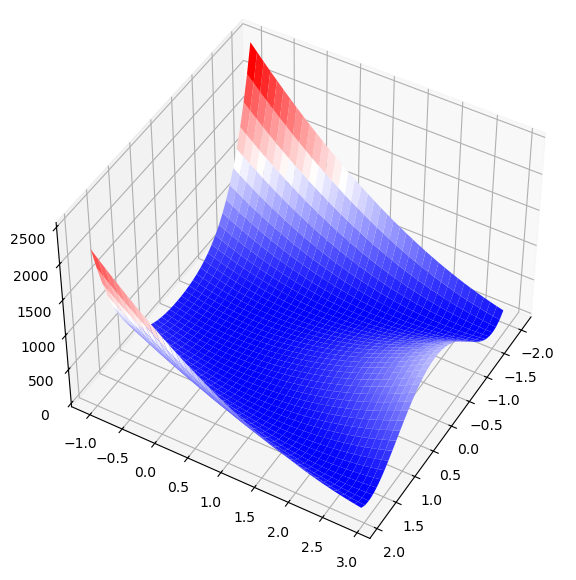

In [2]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.view_init(45, 30)

x = np.arange(-2, 2, 0.1) # создает массив чисел от -2 до 2 с шагом 0.1
y = np.arange(-1, 3, 0.1) # создает массив чисел от -1 до 3 с шагом 0.1
X, Y = np.meshgrid(x, y)
Z = rosenbrock(np.array([X, Y]))

surf = ax.plot_surface(X, Y, Z, cmap='bwr')

plt.show()


In [8]:
from scipy.optimize import differential_evolution

# необходимо определить границы поиска
# будет четерех мерное пространство
bounds = [(-10, 10), (-10, 10), (-10, 10), (-10, 10)]

result = differential_evolution(rosenbrock, bounds, seed=21, recombination=0.6, tol=0.001)
result


 message: Optimization terminated successfully.
 success: True
     fun: 2.3902485428196658e-28
       x: [ 1.000e+00  1.000e+00  1.000e+00  1.000e+00]
     nit: 605
    nfev: 36365